# Assignment 3: EDA Report + Standards Normalization on MIMIC-IV

Dataset: MIMIC-IV Clinical Database Demo v2.2 (100 patients). Code: assignment3_mimic_eda.py (all numbers/figures below are its output; log in assignment3_outputs/run_log.txt).

## Cohort and method notes

Cohort: ALL ICU stays in icustays: 140 stays, 128 hospital admissions, 100 patients. Vitals come from chartevents (HR 220045, RR 220210, SpO2 220277, NIBP systolic 220179, NIBP mean 220181, Temp °C 223762 and Temp °F 223761 converted to °C). Labs come from labevents for the stay's hadm_id with charttime between ICU intime and outtime (creatinine 50912, BUN 51006, potassium 50971, sodium 50983, bicarbonate 50882, glucose 50931, hemoglobin 51222, WBC 51301, platelets 51265, lactate 50813).

Two things to be upfront about:

1. The physiologic range table from “Slide 55” was not among the files I was given, so I could not use it. I used my own conventional impossible-value limits (HR 20–300 bpm, SpO2 50–100 %, Temp 25–45 °C) and also report a stricter sensitivity range. The bounds are one dictionary (RANGES) in the script; if your slide differs, edit it and re-run and the counts in Part A3 update.

2. The d_labitems.csv.gz in this demo has only the columns itemid, label, fluid, category. There is no loinc_code column, so the LOINC coverage answer in Part B is 0 % (see B3), not a number I could estimate from data.

## Part A: Exploratory Data Analysis

**How to run:** put this notebook next to the unzipped `mimic-iv-clinical-database-demo-2.2` folder (or set `MIMIC_DIR` in the first code cell) and choose *Run All*. Explanations under each section are the same as in the Word report; the numbers quoted are from the run saved in this notebook.

In [1]:
"""
Assignment 3: EDA Report + Standards Normalization on MIMIC-IV (demo v2.2)

Usage:  python assignment3_mimic_eda.py [MIMIC_DEMO_DIR] [OUT_DIR]   (or set MIMIC_DIR below; also runs in Jupyter)
Outputs: figures (PNG), tables (CSV) and results.json in OUT_DIR; a printed log.
Cohort : ALL ICU stays in icu/icustays.csv.gz (140 stays, 128 admissions, 100 patients).
Labs   : labevents rows for the stay's hadm_id with charttime inside [intime, outtime].
Vitals : chartevents rows for the stay_id.
"""
import sys, os, json, math
import numpy as np
import pandas as pd
import matplotlib
if "ipykernel" not in sys.modules: matplotlib.use("Agg")   # no GUI needed when run as a script
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ---- Paths --------------------------------------------------------------
# Set MIMIC_DIR to the folder that contains hosp/ and icu/ (the unzipped
# mimic-iv-clinical-database-demo-2.2 folder). Leave None to auto-detect.
MIMIC_DIR = None
OUT_DIR = None            # default: "assignment3_outputs" next to where you run it

IN_NOTEBOOK = "ipykernel" in sys.modules
_args = [] if IN_NOTEBOOK else sys.argv[1:]     # notebooks put kernel args in sys.argv
if len(_args) > 0: MIMIC_DIR = _args[0]
if len(_args) > 1: OUT_DIR = _args[1]

def _find_root():
    here = [os.getcwd()]
    try: here.append(os.path.dirname(os.path.abspath(__file__)))
    except NameError: pass
    home = os.path.expanduser("~")
    bases = here + [os.path.join(home, d) for d in ("Downloads", "Desktop", "Documents")]
    for b in bases:
        for cand in (b, os.path.join(b, "mimic-iv-clinical-database-demo-2.2"),
                     os.path.join(b, "mimic-iv-clinical-database-demo-2.2_1")):
            if os.path.exists(os.path.join(cand, "hosp", "patients.csv.gz")): return cand
        if os.path.isdir(b):
            for n in os.listdir(b):
                c = os.path.join(b, n)
                if n.lower().startswith("mimic-iv") and os.path.exists(os.path.join(c, "hosp", "patients.csv.gz")):
                    return c
                # zip extracted into a folder that wraps another folder
                if os.path.isdir(c) and n.lower().startswith("mimic-iv"):
                    for m in os.listdir(c):
                        cc = os.path.join(c, m)
                        if os.path.exists(os.path.join(cc, "hosp", "patients.csv.gz")): return cc
    return None

ROOT = MIMIC_DIR or _find_root()
if not ROOT or not os.path.exists(os.path.join(ROOT, "hosp", "patients.csv.gz")):
    raise SystemExit("Cannot find MIMIC-IV demo data. Unzip the download and set MIMIC_DIR at the top of "
                     "this file to the folder that contains the 'hosp' and 'icu' sub-folders, e.g. "
                     "MIMIC_DIR = r'C:\\Users\\you\\Downloads\\mimic-iv-clinical-database-demo-2.2'")
OUT = OUT_DIR or os.path.join(os.getcwd(), "assignment3_outputs")
os.makedirs(OUT, exist_ok=True)
print("Data folder:", ROOT, "\nOutput folder:", OUT)
R = {}                                    # results collected for the report
sns.set_theme(style="whitegrid")

def rd(p, **kw): return pd.read_csv(os.path.join(ROOT, p), **kw)
def save(name):
    plt.tight_layout(); plt.savefig(os.path.join(OUT, name), dpi=130)
    if IN_NOTEBOOK: plt.show()          # display inline for screenshots
    plt.close()

Data folder: /tmp/nbrun2/mimic-iv-clinical-database-demo-2.2 
Output folder: /tmp/nbrun2/assignment3_outputs


In [2]:
# ----------------------------------------------------------------------------
# Load
# ----------------------------------------------------------------------------
pat = rd("hosp/patients.csv.gz")
adm = rd("hosp/admissions.csv.gz", parse_dates=["admittime", "dischtime"])
icu = rd("icu/icustays.csv.gz", parse_dates=["intime", "outtime"])
dlab = rd("hosp/d_labitems.csv.gz")
ditem = rd("icu/d_items.csv.gz")
lab = rd("hosp/labevents.csv.gz", parse_dates=["charttime"])
ce = rd("icu/chartevents.csv.gz", parse_dates=["charttime"],
        usecols=["subject_id", "hadm_id", "stay_id", "charttime", "itemid", "valuenum"])

coh = icu.merge(adm[["hadm_id", "hospital_expire_flag"]], on="hadm_id").merge(
    pat[["subject_id", "gender", "anchor_age"]], on="subject_id")
R["cohort"] = dict(stays=len(coh), admissions=int(coh.hadm_id.nunique()),
                   patients=int(coh.subject_id.nunique()))
print("COHORT", R["cohort"])

COHORT {'stays': 140, 'admissions': 128, 'patients': 100}


In [3]:
# ----------------------------------------------------------------------------
# Variable definitions
# ----------------------------------------------------------------------------
VITALS = {220045: "HR", 220210: "RR", 220277: "SpO2", 220179: "SBP", 220181: "MAP",
          223762: "Temp_C", 223761: "Temp_F"}
LABS = {50912: "Creatinine", 51006: "BUN", 50971: "Potassium", 50983: "Sodium",
        50882: "Bicarbonate", 50931: "Glucose", 51222: "Hemoglobin", 51301: "WBC",
        51265: "Platelets", 50813: "Lactate"}
# sanity: itemids exist in dictionaries
assert set(VITALS) <= set(ditem.itemid) and set(LABS) <= set(dlab.itemid)

v = ce[ce.itemid.isin(VITALS)].dropna(subset=["valuenum"]).copy()
v["var"] = v.itemid.map(VITALS)
fmask = v["var"] == "Temp_F"
v.loc[fmask, "valuenum"] = (v.loc[fmask, "valuenum"] - 32) * 5 / 9   # F -> C
v.loc[fmask, "var"] = "Temp_C"
v = v[v.stay_id.isin(coh.stay_id)]

l = lab[lab.itemid.isin(LABS)].dropna(subset=["valuenum", "hadm_id"]).copy()
l["hadm_id"] = l.hadm_id.astype(int)
l = l.merge(coh[["stay_id", "hadm_id", "intime", "outtime"]], on="hadm_id")
l = l[(l.charttime >= l.intime) & (l.charttime <= l.outtime)].copy()
l["var"] = l.itemid.map(LABS)
print("vital rows", len(v), "| lab rows in ICU window", len(l))

vital rows 61825 | lab rows in ICU window 8707


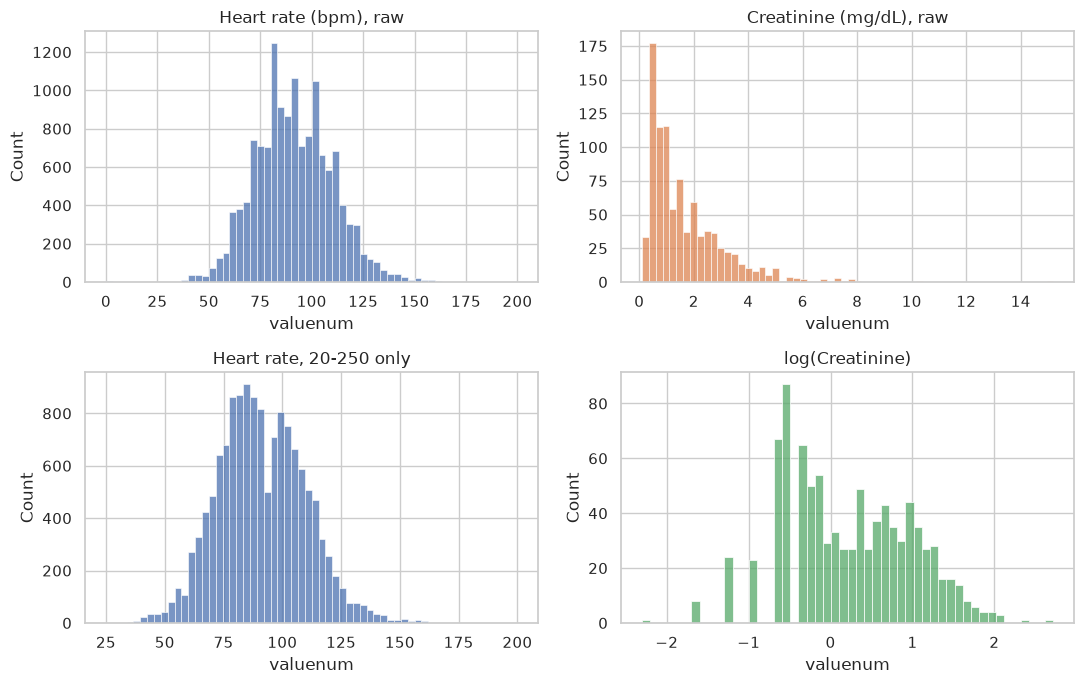

A1 {
 "HR": {
  "n": 13913,
  "mean": 91.12233163228635,
  "sd": 18.689358119703506,
  "median": 90.0,
  "q1": 78.0,
  "q3": 104.0,
  "min": 0.0,
  "max": 200.0,
  "skew": 0.23227052776415397,
  "kurtosis": 0.28872239817505463
 },
 "Creatinine": {
  "n": 923,
  "mean": 1.6953412784398703,
  "sd": 1.4294432450356234,
  "median": 1.2,
  "q1": 0.7,
  "q3": 2.3,
  "min": 0.1,
  "max": 15.2,
  "skew": 2.4301893508941554,
  "kurtosis": 11.608757447690438
 },
 "log_Creatinine_skew": 0.09325593489174984
}


In [4]:
# ----------------------------------------------------------------------------
# A1. Distributions (heart rate, creatinine)
# ----------------------------------------------------------------------------
hr = v[v["var"] == "HR"].valuenum
cr = l[l["var"] == "Creatinine"].valuenum
fig, ax = plt.subplots(2, 2, figsize=(11, 7))
sns.histplot(hr, bins=60, ax=ax[0, 0], color="C0"); ax[0, 0].set_title("Heart rate (bpm), raw")
sns.histplot(cr, bins=60, ax=ax[0, 1], color="C1"); ax[0, 1].set_title("Creatinine (mg/dL), raw")
sns.histplot(np.log(cr), bins=50, ax=ax[1, 1], color="C2"); ax[1, 1].set_title("log(Creatinine)")
sns.histplot(hr[(hr > 20) & (hr < 250)], bins=60, ax=ax[1, 0], color="C0"); ax[1, 0].set_title("Heart rate, 20-250 only")
save("A1_distributions.png")
def desc(s):
    return dict(n=int(len(s)), mean=float(s.mean()), sd=float(s.std()), median=float(s.median()),
                q1=float(s.quantile(.25)), q3=float(s.quantile(.75)), min=float(s.min()),
                max=float(s.max()), skew=float(stats.skew(s)), kurtosis=float(stats.kurtosis(s)))
R["A1"] = {"HR": desc(hr), "Creatinine": desc(cr), "log_Creatinine_skew": float(stats.skew(np.log(cr)))}
pd.DataFrame({"HR": R["A1"]["HR"], "Creatinine": R["A1"]["Creatinine"]}).to_csv(f"{OUT}/A1_summary.csv")
print("A1", json.dumps(R["A1"], indent=1))

### A1. Distributions (10 pts): heart rate and creatinine

Heart rate (n=13,913 charted values): mean 91.1, median 90, SD 18.7, skew 0.23, range 0–200. It is unimodal and close to symmetric with a slightly longer right tail; the only odd feature is a handful of zeros (artefact, see A3). Creatinine (n=923 values): median 1.2 mg/dL (IQR 0.7–2.3), max 15.2, skew 2.43, excess kurtosis 11.6. It is strongly right-skewed with a heavy tail (patients in renal failure); after a log transform the skew falls to 0.09, so it is roughly log-normal and a log transform is appropriate before using it in a linear or distance-based model. Note that the values are repeated measurements within stays, so they are not independent samples.

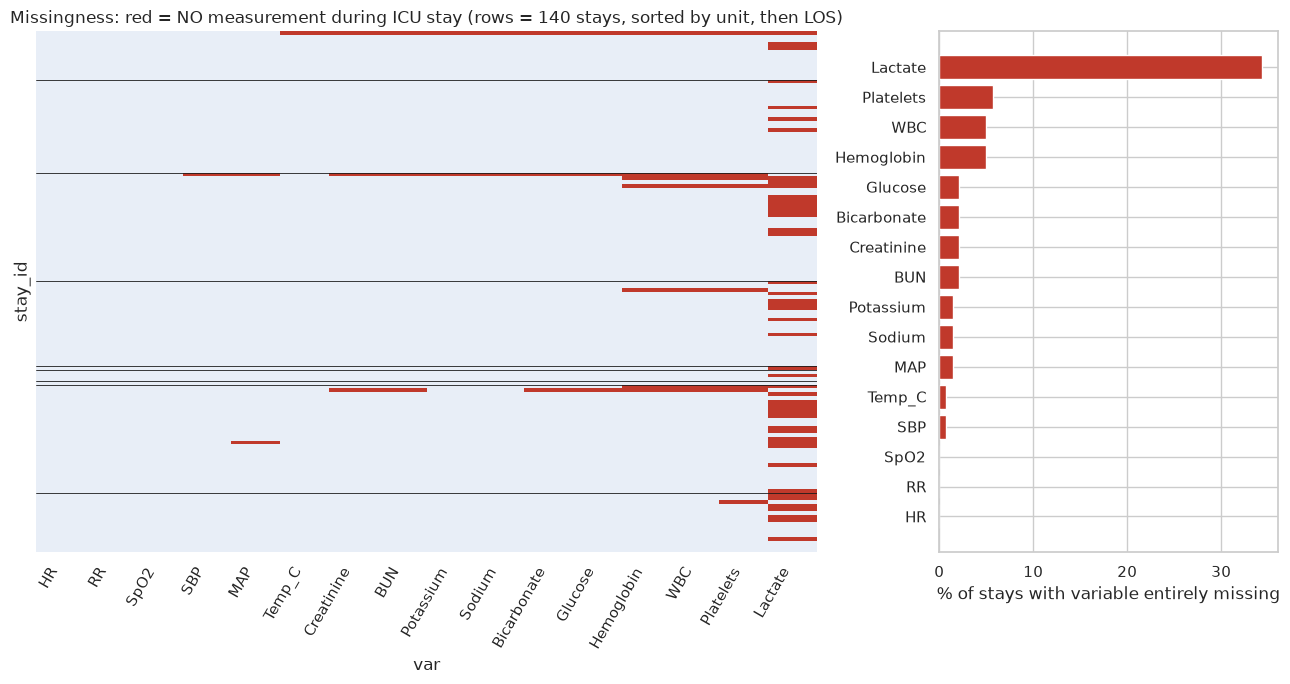

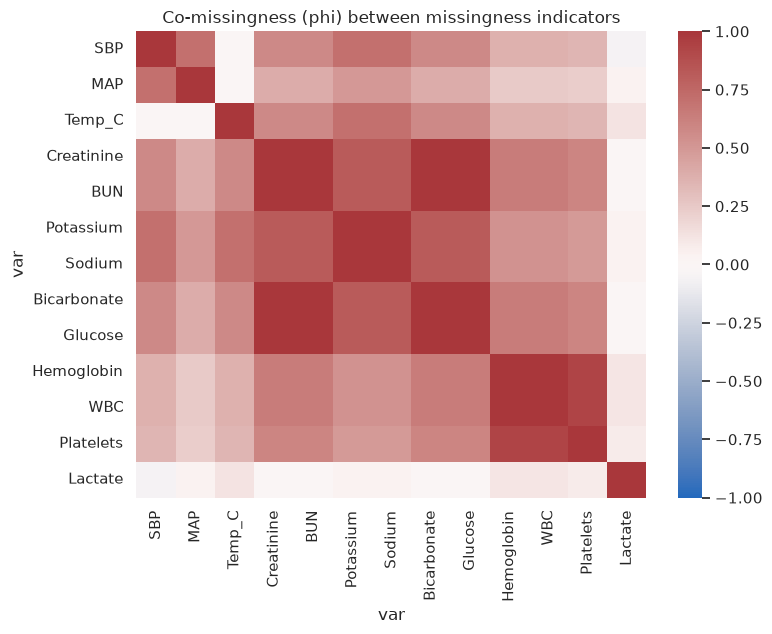

A2 missing % {'HR': 0.0, 'RR': 0.0, 'SpO2': 0.0, 'SBP': 0.7, 'MAP': 1.4, 'Temp_C': 0.7, 'Creatinine': 2.1, 'BUN': 2.1, 'Potassium': 1.4, 'Sodium': 1.4, 'Bicarbonate': 2.1, 'Glucose': 2.1, 'Hemoglobin': 5.0, 'WBC': 5.0, 'Platelets': 5.7, 'Lactate': 34.3}
var                  HR   RR  SpO2  SBP  MAP  Temp_C  Creatinine  BUN  Potassium  Sodium  Bicarbonate  Glucose  Hemoglobin   WBC  Platelets  Lactate  n_stays
CCU                 0.0  0.0   0.0  0.0  0.0     7.7         7.7  7.7        7.7     7.7          7.7      7.7         7.7   7.7        7.7     23.1       13
CVICU               0.0  0.0   0.0  0.0  0.0     0.0         0.0  0.0        0.0     0.0          0.0      0.0         0.0   0.0        0.0     16.0       25
MICU                0.0  0.0   0.0  3.4  3.4     0.0         3.4  3.4        3.4     3.4          3.4      3.4        10.3  10.3       10.3     37.9       29
MICU/SICU           0.0  0.0   0.0  0.0  0.0     0.0         0.0  0.0        0.0     0.0          0.0      0.0    

In [5]:
# ----------------------------------------------------------------------------
# A2. Missingness (stay x variable "any measurement during stay")
# ----------------------------------------------------------------------------
MISS_VARS = ["HR", "RR", "SpO2", "SBP", "MAP", "Temp_C",
             "Creatinine", "BUN", "Potassium", "Sodium", "Bicarbonate", "Glucose",
             "Hemoglobin", "WBC", "Platelets", "Lactate"]
allm = pd.concat([v[["stay_id", "var"]], l[["stay_id", "var"]]], ignore_index=True)
obs = pd.crosstab(allm.stay_id, allm["var"]).reindex(index=coh.stay_id, columns=MISS_VARS, fill_value=0) > 0
obs.index = coh.stay_id.values
miss = ~obs
unit_short = coh.set_index("stay_id").first_careunit.str.extract(r"\((.*)\)")[0].fillna(
    coh.set_index("stay_id").first_careunit)
order = pd.DataFrame({"u": unit_short, "los": coh.set_index("stay_id").los}).sort_values(["u", "los"]).index
fig, ax = plt.subplots(1, 2, figsize=(13, 7), gridspec_kw={"width_ratios": [3, 1.3]})
sns.heatmap(miss.loc[order].astype(int), cmap=["#e8eef7", "#c0392b"], cbar=False, yticklabels=False, ax=ax[0])
ax[0].set_title("Missingness: red = NO measurement during ICU stay (rows = 140 stays, sorted by unit, then LOS)")
bounds = unit_short.loc[order].reset_index(drop=True)
for i in range(1, len(bounds)):
    if bounds[i] != bounds[i - 1]: ax[0].axhline(i, color="k", lw=.6)
plt.setp(ax[0].get_xticklabels(), rotation=60, ha="right")
mr = miss.mean().sort_values()
ax[1].barh(mr.index, mr.values * 100, color="#c0392b"); ax[1].set_xlabel("% of stays with variable entirely missing")
save("A2_missingness.png")
# measurement-level sparsity: observations per stay-day
miss_rate = (miss.mean() * 100).round(1)
by_unit = miss.groupby(unit_short.reindex(miss.index).values).mean().mul(100).round(1)
by_unit["n_stays"] = miss.groupby(unit_short.reindex(miss.index).values).size()
by_unit.to_csv(f"{OUT}/A2_missing_by_unit.csv")
# association of missingness with unit (collapse small units) and with death
ug = unit_short.reindex(miss.index).where(lambda s: s.map(s.value_counts()) >= 13, "Other")
chi = {}
for c in MISS_VARS:
    ct = pd.crosstab(ug.values, miss[c].values)
    chi[c] = float(stats.chi2_contingency(ct)[1]) if ct.shape[1] == 2 else None
died = coh.set_index("stay_id").hospital_expire_flag.reindex(miss.index)
mort_p = {}
for c in MISS_VARS:
    ct = pd.crosstab(died.values, miss[c].values)
    mort_p[c] = float(stats.fisher_exact(ct)[1]) if ct.shape == (2, 2) else None
# co-missingness (phi) among variables that are not constant
mv = miss.loc[:, miss.nunique() > 1].astype(float)
phi = mv.corr()
phi.to_csv(f"{OUT}/A2_missingness_phi.csv")
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(phi, cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax); ax.set_title("Co-missingness (phi) between missingness indicators")
save("A2_comissing_phi.png")
pairs = phi.where(np.triu(np.ones(phi.shape), 1).astype(bool)).stack().sort_values(ascending=False)
R["A2"] = dict(missing_pct=miss_rate.to_dict(), chi2_p_by_unit=chi, fisher_p_by_death=mort_p,
               top_comissing=[(a, b, round(float(x), 2)) for (a, b), x in pairs.head(6).items()],
               n_vars=len(MISS_VARS))
print("A2 missing %", miss_rate.to_dict()); print(by_unit.to_string())
print("chi2 p by unit", {k: (round(x, 4) if x is not None else None) for k, x in chi.items()})
print("fisher p by death", {k: (round(x, 4) if x is not None else None) for k, x in mort_p.items()})
print("top co-missing", R["A2"]["top_comissing"])

### A2. Missingness (10 pts)

Heatmap of 16 variables (6 vitals, 10 labs) across the 140 ICU stays. A cell is red if the variable was never measured during that stay (stay-level missingness, rows sorted by first care unit then length of stay), plus the percentage missing per variable.

Missing % by variable: lactate 34.3%, platelets 5.7%, WBC and hemoglobin 5.0%, chemistry panel (creatinine/BUN/glucose/bicarbonate) 2.1%, K/Na 1.4%, MAP 1.4%, SBP and temperature 0.7%, HR/RR/SpO2 0%.

Interpretation: this is not MCAR. (i) The missingness shows horizontal stripes: the same stays are missing whole groups of variables together (creatinine, BUN, glucose, bicarbonate have phi = 1.0 co-missingness; hemoglobin and WBC are missing in exactly the same stays, with platelets nearly so). That is a panel/ordering mechanism (a lab panel was either drawn or not), not independent random loss. (ii) Lactate is missing in 34 % of stays, far more than any other lab. Lactate is ordered when clinicians suspect shock or sepsis, so whether it is observed depends on the patient's (unobserved) severity, which is MNAR-like. (iii) The 3 stays with no chemistry panel in the ICU window are all very short (LOS 0.02–0.6 days, versus a median of about 2.2 days) and all ended in in-hospital death, so missingness is tied to outcome and stay length (MAR on LOS or MNAR); Fisher's exact test of chemistry-missing vs. death gives p = 0.0025, but with only 3 events this is suggestive, not conclusive. (iv) By contrast, missingness differs little by care unit (chi-square p > 0.1 for every variable, but most unit cells are tiny, so this test is weak). Vitals (HR, RR, SpO2) are essentially complete as they are charted continuously by monitors. Caveat: this is stay-level presence/absence; within-stay sampling frequency (e.g., labs drawn every 6 h vs. daily) is also informative and is a separate form of missingness.

  variable  unit valid_range  n_obs  n_flagged  pct_flagged  n_below  n_above  observed_min  observed_max sens_range  sens_n_flagged  sens_pct
0       HR   bpm      20-300  13913          3       0.0216        3        0           0.0         200.0     30-220               5     0.036
1     SpO2     %      50-100  13540          3       0.0222        3        0          29.0         100.0     70-100               9     0.066
2   Temp_C  degC       25-45   3770          3       0.0796        0        3          31.1          99.0      32-42               5     0.133


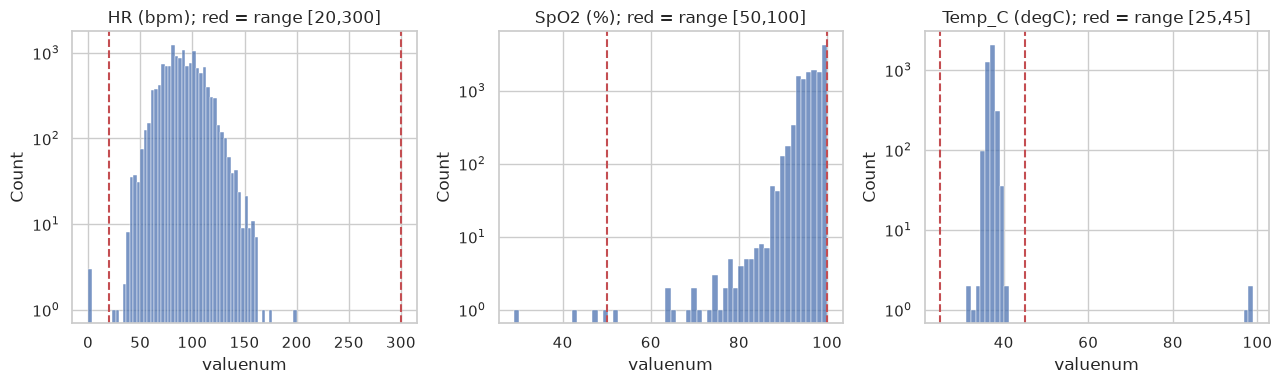

In [6]:
# ----------------------------------------------------------------------------
# A3. Outliers  --  PHYSIOLOGIC RANGE TABLE
# The course "Slide 55" table was not among the files provided, so these bounds are
# my assumption (widely used "impossible value" limits). Edit to match the slide.
# ----------------------------------------------------------------------------
RANGES = {"HR": (20, 300, "bpm"), "SpO2": (50, 100, "%"), "Temp_C": (25, 45, "degC")}
STRICT = {"HR": (30, 220), "SpO2": (70, 100), "Temp_C": (32, 42)}   # sensitivity only
rows = []
for k, (lo, hi, u) in RANGES.items():
    s = v[v["var"] == k].valuenum
    bad = (s < lo) | (s > hi)
    sl, sh = STRICT[k]
    bad2 = (s < sl) | (s > sh)
    rows.append(dict(variable=k, unit=u, valid_range=f"{lo}-{hi}", n_obs=len(s), n_flagged=int(bad.sum()),
                     pct_flagged=round(100 * bad.mean(), 4), n_below=int((s < lo).sum()), n_above=int((s > hi).sum()),
                     observed_min=round(s.min(), 1), observed_max=round(s.max(), 1),
                     sens_range=f"{sl}-{sh}", sens_n_flagged=int(bad2.sum()), sens_pct=round(100 * bad2.mean(), 3)))
out3 = pd.DataFrame(rows); out3.to_csv(f"{OUT}/A3_outliers.csv", index=False)
R["A3"] = rows
print(out3.to_string())
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for a, (k, (lo, hi, u)) in zip(ax, RANGES.items()):
    s = v[v["var"] == k].valuenum
    sns.histplot(s, bins=60, ax=a); a.axvline(lo, color="r", ls="--"); a.axvline(hi, color="r", ls="--")
    a.set_yscale("log"); a.set_title(f"{k} ({u}); red = range [{lo},{hi}]")
save("A3_outliers.png")

### A3. Outliers (10 pts)

| variable | unit | valid_range | n_obs | n_flagged | pct_flagged | n_below | n_above | observed_min | observed_max |
|---|---|---|---|---|---|---|---|---|---|
| HR | bpm | 20-300 | 13913 | 3 | 0.0216 | 3 | 0 | 0.0 | 200.0 |
| SpO2 | % | 50-100 | 13540 | 3 | 0.0222 | 3 | 0 | 29.0 | 100.0 |
| Temp_C | degC | 25-45 | 3770 | 3 | 0.0796 | 0 | 3 | 31.1 | 99.0 |



Range table used (assumption, see notes): HR 20–300, SpO2 50–100, Temp 25–45 °C (Fahrenheit readings converted to °C first). Flagged values: HR: three readings of exactly 0 (artefact/disconnected sensor or asystole not plausible alongside the rest of the record); SpO2: three readings below 50 % (29, 43 and 47 %); temperature: three readings of 97.2, 98.9 and 99.0 charted in the Celsius item, which are clearly Fahrenheit values entered in the wrong field (a unit-entry error). Rates are tiny: 0.022% (HR), 0.022% (SpO2), 0.080% (Temp). With a stricter range (HR 30–220, SpO2 70–100, Temp 32–42 °C) the counts become 5, 9 and 5 (0.036%, 0.066%, 0.133%), so the result is sensitive to where the bounds are drawn, but remains well under 1 %. Flagged values are excluded in A5.

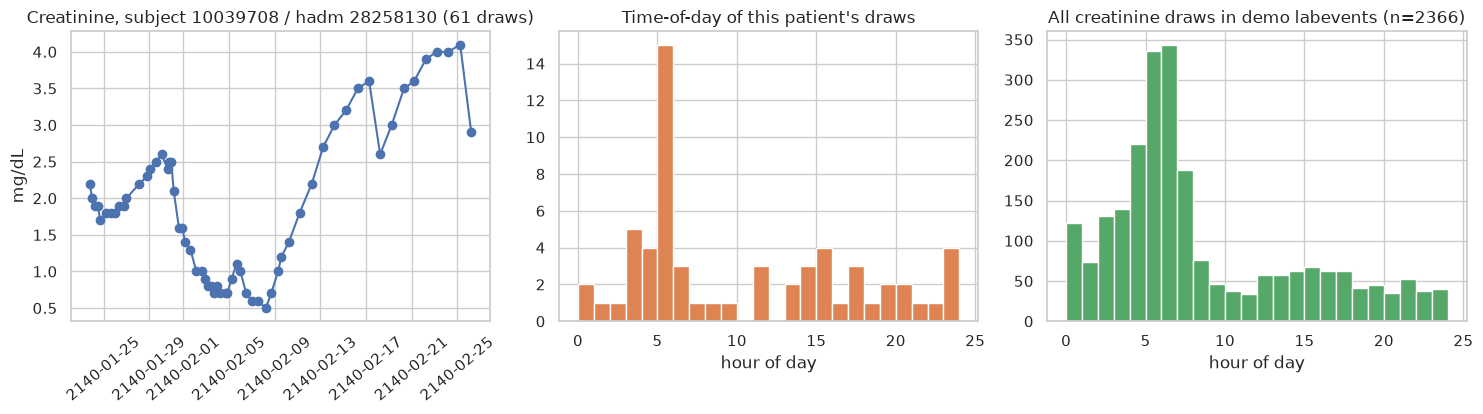

A4 {'subject_id': 10039708, 'hadm_id': 28258130, 'n_draws': 61, 'span_days': 33.4, 'median_gap_h': 11.9, 'gap_iqr': [6.5, 22.8], 'pct_draws_3_to_7am': 43.9, 'pct_this_pt_3_to_7am': 44.3}
[('2140-01-23 19:14:00', 2.2), ('2140-01-23 23:51:00', 2.0), ('2140-01-24 05:51:00', 1.9), ('2140-01-24 11:56:00', 1.9), ('2140-01-24 17:08:00', 1.7), ('2140-01-25 05:00:00', 1.8), ('2140-01-25 15:29:00', 1.8), ('2140-01-26 00:04:00', 1.8), ('2140-01-26 08:45:00', 1.9), ('2140-01-26 18:41:00', 1.9), ('2140-01-27 00:04:00', 2.0), ('2140-01-28 03:38:00', 2.2), ('2140-01-28 19:35:00', 2.3), ('2140-01-29 01:36:00', 2.4), ('2140-01-29 13:55:00', 2.5), ('2140-01-30 02:22:00', 2.6), ('2140-01-30 14:44:00', 2.4), ('2140-01-30 17:45:00', 2.5), ('2140-01-30 22:24:00', 2.5), ('2140-01-31 03:31:00', 2.1), ('2140-01-31 14:30:00', 1.6), ('2140-01-31 21:43:00', 1.6), ('2140-02-01 03:29:00', 1.4), ('2140-02-01 14:43:00', 1.3), ('2140-02-02 03:06:00', 1.0), ('2140-02-02 15:05:00', 1.0), ('2140-02-02 20:41:00', 0.9), ('

In [7]:
# ----------------------------------------------------------------------------
# A4. Temporal pattern - patient/admission with most creatinine draws
# ----------------------------------------------------------------------------
c_all = lab[(lab.itemid == 50912)].dropna(subset=["valuenum", "hadm_id"])
top = c_all.groupby(["subject_id", "hadm_id"]).size().sort_values(ascending=False)
(sid, hid), nd = top.index[0], int(top.iloc[0])
p = c_all[c_all.hadm_id == hid].sort_values("charttime")
gaps = p.charttime.diff().dt.total_seconds().div(3600).dropna()
hrs = c_all.charttime.dt.hour
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
ax[0].plot(p.charttime, p.valuenum, "o-"); ax[0].set_title(f"Creatinine, subject {sid} / hadm {int(hid)} ({nd} draws)")
ax[0].tick_params(axis="x", rotation=40); ax[0].set_ylabel("mg/dL")
ax[1].hist(p.charttime.dt.hour + p.charttime.dt.minute / 60, bins=np.arange(0, 25, 1), color="C1")
ax[1].set_title("Time-of-day of this patient's draws"); ax[1].set_xlabel("hour of day")
ax[2].hist(hrs, bins=np.arange(0, 25, 1), color="C2"); ax[2].set_title(f"All creatinine draws in demo labevents (n={len(hrs)})"); ax[2].set_xlabel("hour of day")
save("A4_temporal.png")
R["A4"] = dict(subject_id=int(sid), hadm_id=int(hid), n_draws=nd,
               span_days=round((p.charttime.max() - p.charttime.min()).total_seconds() / 86400, 1),
               median_gap_h=round(float(gaps.median()), 1), gap_iqr=[round(float(gaps.quantile(.25)), 1), round(float(gaps.quantile(.75)), 1)],
               pct_draws_3_to_7am=round(float(100 * hrs.between(3, 6).mean()), 1),
               pct_this_pt_3_to_7am=round(float(100 * p.charttime.dt.hour.between(3, 6).mean()), 1),
               values=[round(float(x), 2) for x in p.valuenum], times=[str(t) for t in p.charttime])
print("A4", {k: x for k, x in R["A4"].items() if k not in ("values", "times")}); print(list(zip(R["A4"]["times"], R["A4"]["values"])))

### A4. Temporal pattern (10 pts)

Patient chosen: subject_id 10039708, admission 28258130, the admission with the most creatinine draws in the dataset (61 draws over 33.4 days). In the first ~2 weeks draws are every ~6–12 h (median gap over the whole stay 11.9 h, IQR 6.5–22.8 h); from about 10 February onward there is one draw a day at 04:15–07:35. Across all creatinine draws in the demo, 43.9% fall between 03:00 and 06:59 (about 17 % would be expected if draws were uniform over 24 h), and this patient shows the same pattern (44.3%). Interpretation: the sampling times look workflow-driven (a routine morning “AM labs” round) rather than driven by clinical events; the value trajectory itself (falling to 0.5 then rising to 4.1 mg/dL) is clinical, but when it is observed is set by hospital routine. The extra off-schedule draws early in the stay do reflect clinical attention. Practical consequence: timestamps/“time since last lab” features can leak workflow information, and time-aware models should account for the irregular, schedule-driven sampling. (Draws here include the whole hospital admission, not just ICU time.)

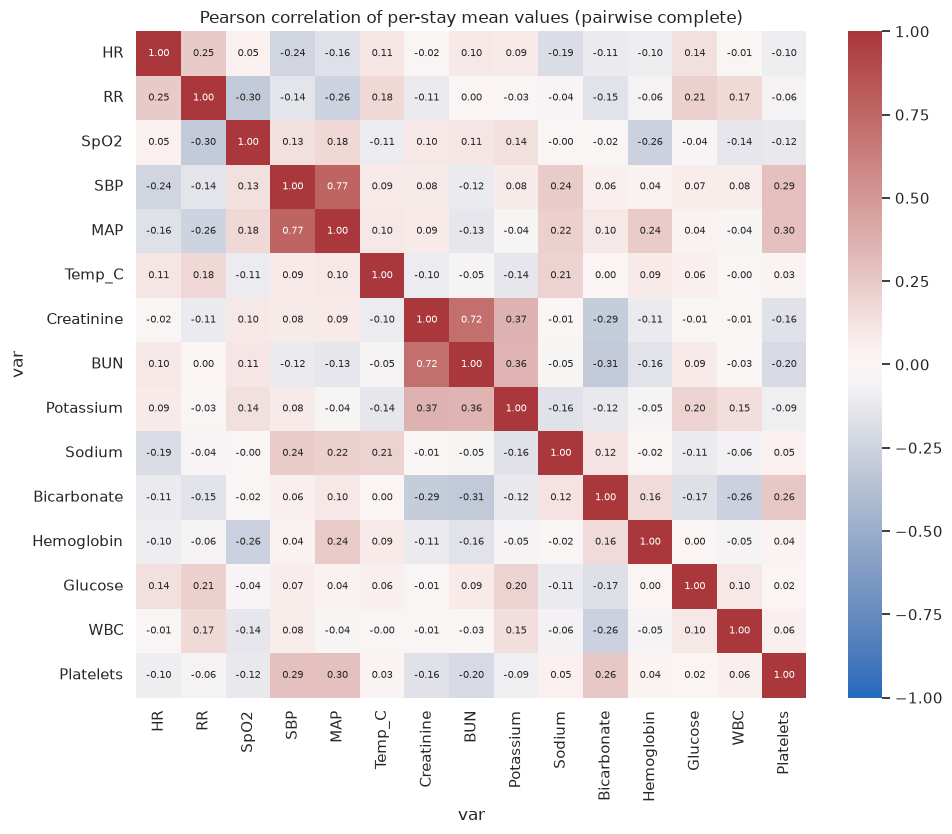

A5 |r|>0.6: [('SBP', 'MAP', 0.768, 138), ('Creatinine', 'BUN', 0.716, 137)]


In [8]:
# ----------------------------------------------------------------------------
# A5. Correlation (per-stay means of cleaned values)
# ----------------------------------------------------------------------------
def clean(df):
    d = df.copy()
    for k, (lo, hi, _) in RANGES.items():
        d = d[~((d["var"] == k) & ((d.valuenum < lo) | (d.valuenum > hi)))]
    return d
feat = pd.concat([clean(v)[["stay_id", "var", "valuenum"]], l[["stay_id", "var", "valuenum"]]], ignore_index=True)
F = feat.groupby(["stay_id", "var"]).valuenum.mean().unstack()
CORR_VARS = ["HR", "RR", "SpO2", "SBP", "MAP", "Temp_C", "Creatinine", "BUN", "Potassium", "Sodium", "Bicarbonate", "Hemoglobin", "Glucose", "WBC", "Platelets"]
Fc = F[CORR_VARS]
Cm = Fc.corr(min_periods=20)
nmat = Fc.notna().astype(int).T @ Fc.notna().astype(int)
fig, ax = plt.subplots(figsize=(10, 8.5))
sns.heatmap(Cm, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax, annot_kws={"size": 7})
ax.set_title("Pearson correlation of per-stay mean values (pairwise complete)")
save("A5_correlation.png")
cp = Cm.where(np.triu(np.ones(Cm.shape), 1).astype(bool)).stack()
strong = cp[cp.abs() > 0.6].sort_values(key=abs, ascending=False)
R["A5"] = dict(n_features=len(CORR_VARS),
               strong=[(a, b, round(float(x), 3), int(nmat.loc[a, b])) for (a, b), x in strong.items()])
print("A5 |r|>0.6:", R["A5"]["strong"])
Cm.round(3).to_csv(f"{OUT}/A5_corr.csv")

### A5. Correlation (10 pts)

Heatmap of per-stay mean values for 15 numeric features (pairwise-complete Pearson, outliers from A3 removed). Two pairs exceed |r| > 0.6: SBP–MAP r = 0.768 (n = 138 stays); Creatinine–BUN r = 0.716 (n = 137 stays). Creatinine–BUN (r = 0.72): both are renal-clearance markers that rise together when glomerular filtration falls (acute kidney injury/chronic kidney disease); BUN is additionally raised by dehydration, GI bleeding and catabolism. SBP–MAP (r = 0.77): mean arterial pressure is computed from systolic and diastolic pressure (MAP ≈ DBP + (SBP − DBP)/3), so the two are mechanically related. No other pair reaches 0.6, so redundancy is limited to these. These are stay-level correlations on a small sample (about 140), so they are descriptive, not causal.

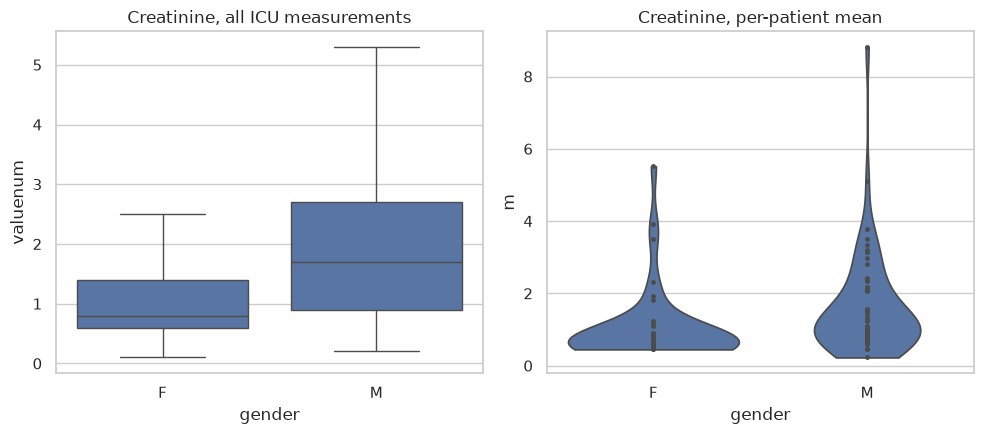

A6 {
 "value_level": {
  "F": {
   "n": 394,
   "median": 0.8,
   "mean": 1.28
  },
  "M": {
   "n": 529,
   "median": 1.7,
   "mean": 2.0
  }
 },
 "patient_level": {
  "F": {
   "n": 43,
   "median": 0.6,
   "mean": 1.02
  },
  "M": {
   "n": 56,
   "median": 1.05,
   "mean": 1.61
  }
 },
 "mwu_p_value_level": 5.042499335232996e-29,
 "mwu_p_patient_level": 1.9015657706894047e-05
}


In [9]:
# ----------------------------------------------------------------------------
# A6. Subgroup shift: creatinine by gender
# ----------------------------------------------------------------------------
lc = l[l["var"] == "Creatinine"].merge(coh[["stay_id", "subject_id", "gender"]].drop_duplicates("stay_id"), on="stay_id", suffixes=("", "_c"))
pp = lc.groupby(["subject_id_c" if "subject_id_c" in lc else "subject_id", "gender"]).valuenum.mean().reset_index(name="m")
fig, ax = plt.subplots(1, 2, figsize=(10, 4.5))
sns.boxplot(data=lc, x="gender", y="valuenum", ax=ax[0], showfliers=False); ax[0].set_title("Creatinine, all ICU measurements")
sns.violinplot(data=pp, x="gender", y="m", ax=ax[1], cut=0, inner="point"); ax[1].set_title("Creatinine, per-patient mean")
save("A6_subgroup.png")
g = {s: lc[lc.gender == s].valuenum for s in ["F", "M"]}
gp = {s: pp[pp.gender == s].m for s in ["F", "M"]}
R["A6"] = dict(
    value_level={s: dict(n=int(len(x)), median=round(float(x.median()), 2), mean=round(float(x.mean()), 2)) for s, x in g.items()},
    patient_level={s: dict(n=int(len(x)), median=round(float(x.median()), 2), mean=round(float(x.mean()), 2)) for s, x in gp.items()},
    mwu_p_value_level=float(stats.mannwhitneyu(g["F"], g["M"]).pvalue),
    mwu_p_patient_level=float(stats.mannwhitneyu(gp["F"], gp["M"]).pvalue))
print("A6", json.dumps(R["A6"], indent=1))

### A6. Subgroup shift (10 pts): creatinine by gender

All ICU creatinine measurements: women n = 394, median 0.8 mg/dL (mean 1.28); men n = 529, median 1.7 (mean 2.0); Mann–Whitney p = 5.0e-29. Because measurements are clustered within patients, I repeated the test on per-patient means: women n = 43, median 0.6; men n = 56, median 1.05; p = 1.9e-05. Men have clearly higher creatinine under both analyses. Part of this is physiological (higher muscle mass and creatinine production in men, so reference ranges differ by sex), and part may be case-mix (age, kidney disease, severity) that I did not adjust for. The practical point is that a model using raw creatinine sees a different distribution by sex, so a sex-specific reference or a fairness check is warranted. The small sample (100 patients) limits how far this generalizes.

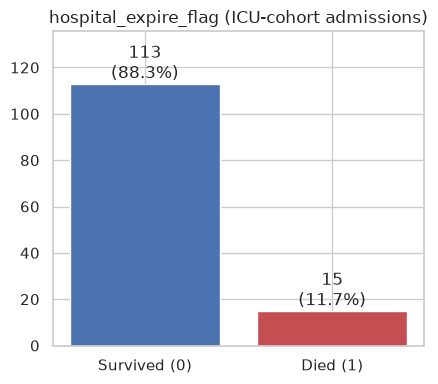

A7 {'cohort_admissions': {0: 113, 1: 15}, 'cohort_stays': {0: 120, 1: 20}, 'all_admissions': {0: 260, 1: 15}, 'death_rate_pct': np.float64(11.7), 'imbalance': np.float64(7.53)}


In [10]:
# ----------------------------------------------------------------------------
# A7. Label distribution
# ----------------------------------------------------------------------------
ca = coh.drop_duplicates("hadm_id")
vc = ca.hospital_expire_flag.value_counts().sort_index()
vs = coh.hospital_expire_flag.value_counts().sort_index()
va = adm.hospital_expire_flag.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.bar(["Survived (0)", "Died (1)"], vc.values, color=["C0", "C3"])
for i, x in enumerate(vc.values): ax.text(i, x, f"{x}\n({100*x/vc.sum():.1f}%)", ha="center", va="bottom")
ax.set_ylim(0, vc.max() * 1.2); ax.set_title("hospital_expire_flag (ICU-cohort admissions)")
save("A7_label.png")
R["A7"] = dict(cohort_admissions={int(k): int(x) for k, x in vc.items()}, cohort_stays={int(k): int(x) for k, x in vs.items()},
               all_admissions={int(k): int(x) for k, x in va.items()},
               death_rate_pct=round(100 * vc.get(1, 0) / vc.sum(), 1), imbalance=round(vc.max() / vc.min(), 2))
print("A7", R["A7"])

### A7. Label distribution (10 pts)

hospital_expire_flag among the 128 admissions with an ICU stay: 113 survived (0) and 15 died (1), a mortality of 11.7% (imbalance ≈ 7.53:1). At the stay level (a stay inherits its admission's flag) it is 120 vs 20; I report admission-level numbers because stays from the same admission share a label. For all 275 admissions in the demo it is 260 vs 15 (the 15 deaths all occur in ICU admissions). The classes are imbalanced, so plain accuracy is misleading (always predicting survival gives 88 %); use AUROC/AUPRC, class weights or resampling, stratified splits, and note that with only 15 positives any model estimate will have very wide uncertainty. Patient-level (not row-level) splits are needed to avoid leakage.

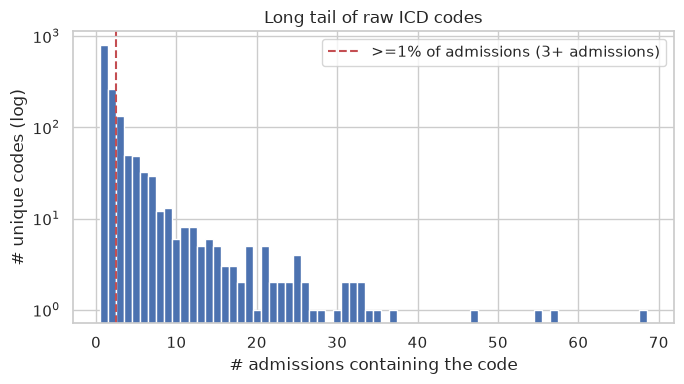

B1 {'n_admissions': 275, 'n_rows': 4506, 'unique_raw_codes': 1474, 'unique_raw_codes_ignoring_version': 1472, 'threshold_admissions': 3, 'codes_ge_1pct': 401, 'icd9_rows': 2193, 'icd10_rows': 2313, 'max_prevalence_pct': np.float64(24.7), 'all_codes_in_dictionary': True}
         code  n_adm   pct                                                                                                  long_title
0      9:4019     68  24.7                                                                          Unspecified essential hypertension
1     10:E785     57  20.7                                                                                 Hyperlipidemia, unspecified
2      9:2724     55  20.0                                                                        Other and unspecified hyperlipidemia
3     10:E039     47  17.1                                                                                 Hypothyroidism, unspecified
4     10:Z794     37  13.5                            

In [11]:
# ----------------------------------------------------------------------------
# B1/B2. ICD
# ----------------------------------------------------------------------------
dx = rd("hosp/diagnoses_icd.csv.gz", dtype={"icd_code": str}); ddx = rd("hosp/d_icd_diagnoses.csv.gz", dtype={"icd_code": str})
dx["icd_code"] = dx.icd_code.str.strip()
n_adm = dx.hadm_id.nunique()
dx["code"] = dx.icd_version.astype(str) + ":" + dx.icd_code      # version-qualified (ICD-9 and ICD-10 collide otherwise)
per_code = dx.groupby("code").hadm_id.nunique()
thr = math.ceil(0.01 * n_adm)
common = per_code[per_code >= thr]
R["B1"] = dict(n_admissions=int(n_adm), n_rows=len(dx), unique_raw_codes=int(per_code.size),
               unique_raw_codes_ignoring_version=int(dx.icd_code.nunique()),
               threshold_admissions=int(thr), codes_ge_1pct=int(common.size),
               icd9_rows=int((dx.icd_version == 9).sum()), icd10_rows=int((dx.icd_version == 10).sum()),
               max_prevalence_pct=round(100 * per_code.max() / n_adm, 1),
               all_codes_in_dictionary=bool(dx.merge(ddx, on=["icd_code", "icd_version"], how="left").long_title.notna().all()))
top = common.sort_values(ascending=False).head(15).rename("n_adm").reset_index()
top[["v", "c"]] = top.code.str.split(":", expand=True)
top = top.merge(ddx.rename(columns={"icd_version": "v2"}).assign(v=lambda d: d.v2.astype(str)), left_on=["v", "c"], right_on=["v", "icd_code"], how="left")
top["pct"] = (100 * top.n_adm / n_adm).round(1)
top[["code", "n_adm", "pct", "long_title"]].to_csv(f"{OUT}/B1_top_codes.csv", index=False)
R["B1"]["top"] = top[["code", "n_adm", "pct", "long_title"]].values.tolist()
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(per_code.values, bins=np.arange(0.5, per_code.max() + 1.5), color="C0"); ax.set_yscale("log")
ax.axvline(thr - 0.5, color="r", ls="--", label=f">=1% of admissions ({thr}+ admissions)")
ax.set_xlabel("# admissions containing the code"); ax.set_ylabel("# unique codes (log)"); ax.legend(); ax.set_title("Long tail of raw ICD codes")
save("B1_long_tail.png")
print("B1", {k: x for k, x in R["B1"].items() if k != "top"}); print(top[["code", "n_adm", "pct", "long_title"]].to_string())

# roll-up to 3-character family: first 3 chars of the code, per ICD version
dx["family"] = dx.icd_version.astype(str) + ":" + dx.icd_code.str[:3]
fam = dx.groupby("family").hadm_id.nunique()
top20 = per_code.sort_values(ascending=False).head(20).index
ex = pd.DataFrame({"raw_code": top20, "family": [c.split(":")[0] + ":" + c.split(":")[1][:3] for c in top20]})
ex.to_csv(f"{OUT}/B2_rollup_top20.csv", index=False)
multi = dx.groupby("family").code.nunique(); multi = multi[multi > 1]
R["B2"] = dict(unique_raw=int(per_code.size), unique_families=int(fam.size),
               reduction_pct=round(100 * (1 - fam.size / per_code.size), 1),
               top20_unique_raw=20, top20_unique_families=int(ex.family.nunique()),
               families_ge_1pct=int((fam >= thr).sum()),
               families_with_multiple_raw=int(len(multi)), example=ex.head(8).values.tolist(),
               e_v_code_note=int(dx.icd_code.str.match(r"^[EV]").sum()))
print("B2", {k: x for k, x in R["B2"].items()})
print(ex.to_string())

## Part B: Standards Normalization

### B1. Raw ICD codes vs. codes in ≥1 % of admissions (10 pts)

I used all 275 admissions that have diagnoses (4,506 diagnosis rows; requirement was 200+). Every code was found in d_icd_diagnoses (joined on icd_code + icd_version). ICD-9 and ICD-10 codes coexist in MIMIC-IV, so a code is identified as version:code.

| Metric | Value |
|---|---|
| Unique raw ICD codes (version + code) | 1474 |
| (ignoring version, for reference) | 1472 |
| Unique codes in ≥1% of admissions (≥3 of 275, since 1% of 275 = 2.75) | 401 |
| Share of unique codes that reach 1% | 27.2% |



Most-prevalent codes (note that the same concept appears under both ICD versions, e.g. hypertension 4019 vs I10, hyperlipidemia 2724 vs E785):

| code | admissions | % | description |
|---|---|---|---|
| 9:4019 | 68 | 24.7 | Unspecified essential hypertension |
| 10:E785 | 57 | 20.7 | Hyperlipidemia, unspecified |
| 9:2724 | 55 | 20.0 | Other and unspecified hyperlipidemia |
| 10:E039 | 47 | 17.1 | Hypothyroidism, unspecified |
| 10:Z794 | 37 | 13.5 | Long term (current) use of insulin |
| 10:Z87891 | 35 | 12.7 | Personal history of nicotine dependence |
| 9:42731 | 34 | 12.4 | Atrial fibrillation |
| 10:I2510 | 33 | 12.0 | Atherosclerotic heart disease of native coronary artery without angina |
| 9:25000 | 33 | 12.0 | Diabetes mellitus without mention of complication, type II or unspecif |
| 10:I10 | 32 | 11.6 | Essential (primary) hypertension |
| 10:F329 | 32 | 11.6 | Major depressive disorder, single episode, unspecified |
| 9:V1582 | 31 | 11.3 | Personal history of tobacco use |
| 10:N179 | 31 | 11.3 | Acute kidney failure, unspecified |
| 9:311 | 30 | 10.9 | Depressive disorder, not elsewhere classified |
| 9:41401 | 28 | 10.2 | Coronary atherosclerosis of native coronary artery |



Interpretation: the vocabulary is a long tail: 1474 distinct codes but only 401 appear in at least 1% of admissions, and the most common code covers only 24.7% of admissions. Most codes occur in one or two admissions, which is too few to learn from, motivating rollup and frequency thresholds. (In this 100-patient demo the 1% cut-off is only 3 admissions, so the count would be much smaller in full MIMIC-IV.)

### B2. Roll-up to 3-character ICD families (5 pts)

| raw code (version:code) | 3-char family |
|---|---|
| 9:4019 | 9:401 |
| 10:E785 | 10:E78 |
| 9:2724 | 9:272 |
| 10:E039 | 10:E03 |
| 10:Z794 | 10:Z79 |
| 10:Z87891 | 10:Z87 |
| 9:42731 | 9:427 |
| 9:25000 | 9:250 |
| 10:I2510 | 10:I25 |
| 10:F329 | 10:F32 |
| 10:I10 | 10:I10 |
| 10:N179 | 10:N17 |
| 9:V1582 | 9:V15 |
| 9:311 | 9:311 |
| 9:41401 | 9:414 |
| 9:40390 | 9:403 |
| 10:E119 | 10:E11 |
| 10:F419 | 10:F41 |
| 9:5849 | 9:584 |
| 9:V5867 | 9:V58 |



The 20 most frequent codes above map to 20 distinct families (none collapse because these frequent codes already belong to different families). Applied to ALL 1474 unique raw codes, the roll-up leaves 688 unique categories, a 53.3% reduction; 337 of these families occur in ≥1% of admissions (versus 401 raw codes), and 313 families merge two or more raw codes. Caveats: (1) the roll-up is done within each ICD version, so equivalent ICD-9 and ICD-10 concepts (9:401 vs 10:I10) stay separate until a cross-version map (e.g., GEMs) is applied; (2) ICD-9 E-codes properly have a 4-character family, and a plain 3-character cut is coarser for them; (3) MIMIC stores codes without the dot, so J18.9 appears as J189 and rolls up to J18.

In [12]:
# ----------------------------------------------------------------------------
# B3. LOINC coverage of lab itemids
# ----------------------------------------------------------------------------
ids = lab.itemid.drop_duplicates()
dl = dlab[dlab.itemid.isin(ids)]
has_col = "loinc_code" in dlab.columns
R["B3"] = dict(d_labitems_columns=list(dlab.columns), n_itemids_in_labevents=int(ids.nunique()),
               n_in_dictionary=int(dl.itemid.nunique()), loinc_column_present=has_col)
if has_col:
    R["B3"]["n_with_loinc"] = int(dl.loinc_code.notna().sum())
    R["B3"]["fraction_with_loinc"] = round(float(dl.loinc_code.notna().mean()), 4)
else:
    R["B3"]["n_with_loinc"] = 0; R["B3"]["fraction_with_loinc"] = 0.0
# what a fallback must cope with: label/fluid/category shape of the (unmapped) items
R["B3"]["by_fluid"] = dl.fluid.value_counts().to_dict()
R["B3"]["by_category"] = dl.category.value_counts().to_dict()
lab_ct = lab.itemid.value_counts()
R["B3"]["top10_items"] = [(int(i), dlab.set_index("itemid").label[i], dlab.set_index("itemid").fluid[i], int(n)) for i, n in lab_ct.head(10).items()]
cs = lab_ct.cumsum() / lab_ct.sum()
R["B3"]["event_share_top"] = {n: round(float(cs.iloc[n - 1]), 3) for n in (10, 25, 50, 100)}
dup = dl.assign(l=dl.label.str.lower().str.strip()).groupby("l").itemid.nunique(); dup = dup[dup > 1]
R["B3"]["duplicate_labels_across_itemids"] = int(len(dup))
print("B3", json.dumps(R["B3"], indent=1))

json.dump(R, open(f"{OUT}/results.json", "w"), indent=1, default=str)
print("done")

B3 {
 "d_labitems_columns": [
  "itemid",
  "label",
  "fluid",
  "category"
 ],
 "n_itemids_in_labevents": 498,
 "n_in_dictionary": 498,
 "loinc_column_present": false,
 "n_with_loinc": 0,
 "fraction_with_loinc": 0.0,
 "by_fluid": {
  "Blood": 289,
  "Urine": 86,
  "Other Body Fluid": 39,
  "Bone Marrow": 26,
  "Ascites": 21,
  "Pleural": 18,
  "Cerebrospinal Fluid": 8,
  "Joint Fluid": 8,
  "Stool": 3
 },
 "by_category": {
  "Hematology": 238,
  "Chemistry": 227,
  "Blood Gas": 33
 },
 "top10_items": [
  [
   50971,
   "Potassium",
   "Blood",
   3022
  ],
  [
   50983,
   "Sodium",
   "Blood",
   3007
  ],
  [
   50912,
   "Creatinine",
   "Blood",
   3003
  ],
  [
   50902,
   "Chloride",
   "Blood",
   2981
  ],
  [
   51006,
   "Urea Nitrogen",
   "Blood",
   2974
  ],
  [
   51221,
   "Hematocrit",
   "Blood",
   2913
  ],
  [
   50882,
   "Bicarbonate",
   "Blood",
   2863
  ],
  [
   50868,
   "Anion Gap",
   "Blood",
   2860
  ],
  [
   51265,
   "Platelet Count",
   "Blood",

### B3. LOINC coverage of lab itemids (5 pts)

The dataset has 498 distinct itemids in labevents, all present in d_labitems. The d_labitems table in this download has the columns itemid, label, fluid, category, with no loinc_code column. Therefore the fraction of itemids with a non-null LOINC code is 0/498 = 0%. I did not find LOINC codes anywhere else in the download (a text search of the package for “loinc” returned nothing). If your course materials show a loinc_code column, it comes from a different release of d_labitems; the script handles this: if the column exists it computes the true non-null fraction.

For scale: the itemids split into fluid Blood 289, Urine 86 and others, and categories Hematology 238, Chemistry 227, Blood Gas 33. The top 25 itemids account for 58% of lab events and the top 50 for 79%, so manual curation of the head is cheap and covers most of the data. 46 lower-cased labels are shared by more than one itemid (usually the same test with a different fluid or analyzer).

### B4. Fallback strategy for itemids without a LOINC code (10 pts)

1. Curate the head by hand. Rank itemids by event count and have a clinician or informatician map the top ~50–100 to LOINC (this covers about 79–94% of events here). Store the result as a reviewed crosswalk table (itemid → LOINC, mapping method, confidence, reviewer).

2. Normalize label strings for the tail. Lower-case, strip punctuation and extra whitespace, expand abbreviations (e.g., “Urea Nitrogen” = BUN, “WBC” = white blood cell count, “Hct” = hematocrit), and remove assay modifiers. Then exact-match against LOINC long common names and the LOINC “component” field.

3. Use more than the name. A LOINC code is defined by component, property, time, system (specimen), scale and method, so build the query from several fields: label → component; the fluid column (Blood, Urine, CSF, Pleural...) → system; valueuom (mg/dL, mEq/L, %, #/uL) → property type and unit; category (Chemistry/Hematology/Blood Gas) as a sanity check; and the reference range (ref_range_lower/upper) as a plausibility check. Two itemids with the same label but different fluid must not map to the same code.

4. Fuzzy and embedding matching with human review. For labels without an exact match, rank LOINC candidates by token-set or character n-gram similarity (e.g., TF-IDF cosine, Jaro-Winkler) and optionally by embeddings from a biomedical language model (SapBERT or similar); accept automatically only above a high threshold and when fluid and unit agree, and queue the rest for review.

5. Use value-distribution evidence. Compare the itemid's observed unit and value distribution with that of a confidently mapped item (for example, a sodium-like range around 135–145 mmol/L supports a sodium mapping) to detect and fix wrong matches.

6. Fail safe. Items that remain unmatched keep their local itemid as a namespaced code (e.g., MIMIC:51234) rather than being dropped, are flagged “unmapped”, and are excluded from or handled separately in cross-site models. Validate the pipeline by measuring precision on a held-out, hand-labelled sample of mapped items, and version the crosswalk so the mapping is reproducible.

## Reproducibility

Notebook: Run All. The `.py` script (`assignment3_mimic_eda.py`) does the same analysis from the command line; `build_report.py` builds the Word report.